In [5]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from mlxtend.frequent_patterns import apriori, association_rules
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [6]:
# Step 2: Load and explore the dataset
df = pd.read_csv('user_personalized_features.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (1000, 15)

First few rows:


,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


In [7]:
# Step 3: Data Exploration and Preprocessing
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Basic statistics
print("\nDescriptive Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   1000 non-null   int64 
 1   User_ID                      1000 non-null   object
 2   Age                          1000 non-null   int64 
 3   Gender                       1000 non-null   object
 4   Location                     1000 non-null   object
 5   Income                       1000 non-null   int64 
 6   Interests                    1000 non-null   object
 7   Last_Login_Days_Ago          1000 non-null   int64 
 8   Purchase_Frequency           1000 non-null   int64 
 9   Average_Order_Value          1000 non-null   int64 
 10  Total_Spending               1000 non-null   int64 
 11  Product_Category_Preference  1000 non-null   object
 12  Time_Spent_on_Site_Minutes   1000 non-null   int64 
 13  Pages_Viewed        

,Unnamed: 0,Age,Income,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Time_Spent_on_Site_Minutes,Pages_Viewed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,499.500000,40.986000,81304.732000,15.586000,4.631000,104.039000,2552.957000,297.360000,24.40300
std,288.819436,13.497852,37363.972753,8.205604,2.837762,54.873569,1420.985048,175.596123,14.02017
min,0.000000,18.000000,20155.000000,1.000000,0.000000,10.000000,112.000000,2.000000,1.00000
25%,249.750000,29.000000,48715.500000,8.000000,2.000000,58.000000,1271.750000,144.000000,12.00000
50%,499.500000,42.000000,81042.000000,16.000000,5.000000,105.000000,2542.000000,292.500000,24.50000
75%,749.250000,52.000000,112694.500000,23.000000,7.000000,150.000000,3835.500000,449.250000,36.00000
max,999.000000,64.000000,149951.000000,29.000000,9.000000,199.000000,4999.000000,599.000000,49.00000


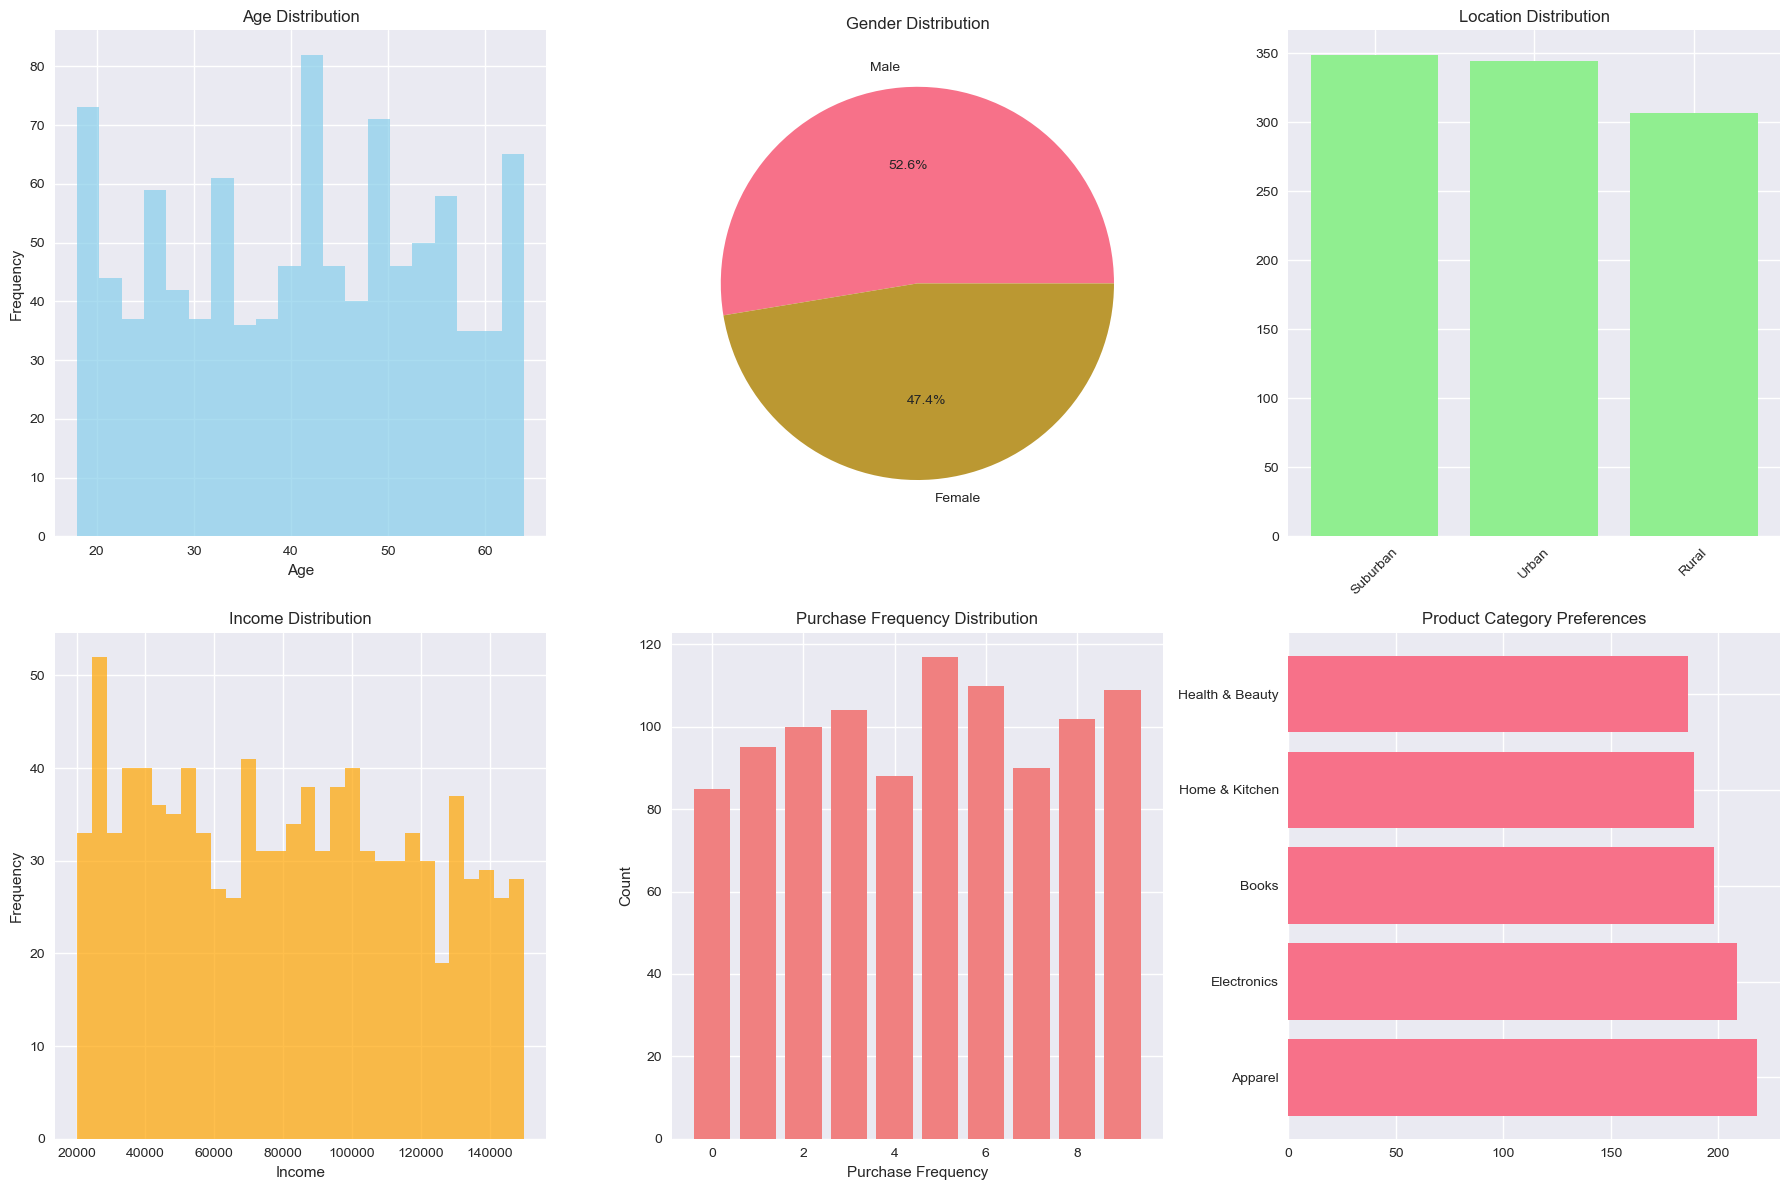

In [8]:
# Step 4: Visualize the data distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Age distribution
axes[0,0].hist(df['Age'], bins=20, alpha=0.7, color='skyblue')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[0,1].set_title('Gender Distribution')

# Location distribution
location_counts = df['Location'].value_counts()
axes[0,2].bar(location_counts.index, location_counts.values, color='lightgreen')
axes[0,2].set_title('Location Distribution')
axes[0,2].tick_params(axis='x', rotation=45)

# Income distribution
axes[1,0].hist(df['Income'], bins=30, alpha=0.7, color='orange')
axes[1,0].set_title('Income Distribution')
axes[1,0].set_xlabel('Income')
axes[1,0].set_ylabel('Frequency')

# Purchase Frequency
purchase_freq = df['Purchase_Frequency'].value_counts().sort_index()
axes[1,1].bar(purchase_freq.index, purchase_freq.values, color='lightcoral')
axes[1,1].set_title('Purchase Frequency Distribution')
axes[1,1].set_xlabel('Purchase Frequency')
axes[1,1].set_ylabel('Count')

# Product Category Preference
category_counts = df['Product_Category_Preference'].value_counts()
axes[1,2].barh(range(len(category_counts)), category_counts.values)
axes[1,2].set_yticks(range(len(category_counts)))
axes[1,2].set_yticklabels(category_counts.index)
axes[1,2].set_title('Product Category Preferences')

plt.tight_layout()
plt.show()

In [9]:
# Step 5: Data Preprocessing for Recommendation Systems
# Create a copy of the dataframe for processing
df_processed = df.copy()

# Encode categorical variables
label_encoders = {}
categorical_columns = ['Gender', 'Location', 'Interests', 'Product_Category_Preference']

for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

# Create user-category matrix for collaborative filtering
user_category_matrix = pd.get_dummies(df_processed['Product_Category_Preference'], prefix='Category')
user_category_matrix['User_ID'] = df_processed['User_ID']

print("User-Category Matrix Shape:", user_category_matrix.shape)
user_category_matrix.head()

User-Category Matrix Shape: (1000, 6)


,Category_Apparel,Category_Books,Category_Electronics,Category_Health & Beauty,Category_Home & Kitchen,User_ID
0,False,True,False,False,False,#1
1,False,False,True,False,False,#2
2,True,False,False,False,False,#3
3,True,False,False,False,False,#4
4,False,False,False,True,False,#5


In [10]:
# Step 6: Association Rule Mining
print("=== ASSOCIATION RULE MINING ===")

# Prepare data for association rule mining
# We'll use user interests and product categories as items
basket_data = []

for idx, row in df_processed.iterrows():
    items = [
        f"Gender_{row['Gender']}",
        f"Location_{row['Location']}",
        f"Interest_{row['Interests']}",
        f"Category_{row['Product_Category_Preference']}",
        f"Income_Level_{'High' if row['Income'] > 80000 else 'Medium' if row['Income'] > 50000 else 'Low'}",
        f"Age_Group_{'Young' if row['Age'] < 30 else 'Middle' if row['Age'] < 50 else 'Senior'}"
    ]
    basket_data.append(items)

# Convert to transaction format for association rules
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(basket_data).transform(basket_data)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print("Basket Data Shape:", basket_df.shape)
print("\nSample of basket data:")
basket_df.iloc[:5, :10].head()

=== ASSOCIATION RULE MINING ===
Basket Data Shape: (1000, 21)

Sample of basket data:


,Age_Group_Middle,Age_Group_Senior,Age_Group_Young,Category_Apparel,Category_Books,Category_Electronics,Category_Health & Beauty,Category_Home & Kitchen,Gender_Female,Gender_Male
0,False,True,False,False,True,False,False,False,False,True
1,True,False,False,False,False,True,False,False,True,False
2,True,False,False,True,False,False,False,False,True,False
3,False,True,False,True,False,False,False,False,True,False
4,False,False,True,False,False,False,True,False,False,True


In [11]:
# Step 7: Generate Frequent Itemsets and Association Rules
# Find frequent itemsets
frequent_itemsets = apriori(basket_df, min_support=0.05, use_colnames=True, max_len=3)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print("Top 10 Frequent Itemsets:")
print(frequent_itemsets.head(10))

# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
rules = rules.sort_values('lift', ascending=False)

print(f"\nGenerated {len(rules)} association rules")
print("\nTop 10 Association Rules (by Lift):")
top_rules = rules.head(10)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
top_rules

Top 10 Frequent Itemsets:
     support                          itemsets
9      0.526                     (Gender_Male)
10     0.505               (Income_Level_High)
8      0.474                   (Gender_Female)
0      0.426                (Age_Group_Middle)
19     0.349               (Location_Suburban)
20     0.344                  (Location_Urban)
1      0.319                (Age_Group_Senior)
18     0.307                  (Location_Rural)
120    0.278  (Income_Level_High, Gender_Male)
11     0.266                (Income_Level_Low)

Generated 560 association rules

Top 10 Association Rules (by Lift):


,antecedents,consequents,support,confidence,lift
526,(Location_Suburban),"(Category_Books, Gender_Male)",0.051,0.146132,1.391731
523,"(Category_Books, Gender_Male)",(Location_Suburban),0.051,0.485714,1.391731
520,(Category_Books),(Interest_Technology),0.051,0.257576,1.384816
521,(Interest_Technology),(Category_Books),0.051,0.274194,1.384816
525,(Category_Books),"(Location_Suburban, Gender_Male)",0.051,0.257576,1.287879
524,"(Location_Suburban, Gender_Male)",(Category_Books),0.051,0.255000,1.287879
522,"(Category_Books, Location_Suburban)",(Gender_Male),0.051,0.653846,1.243054
412,"(Age_Group_Middle, Income_Level_High)",(Category_Electronics),0.057,0.255605,1.222992
413,(Category_Electronics),"(Age_Group_Middle, Income_Level_High)",0.057,0.272727,1.222992
511,(Income_Level_Medium),(Category_Health & Beauty),0.052,0.227074,1.220829


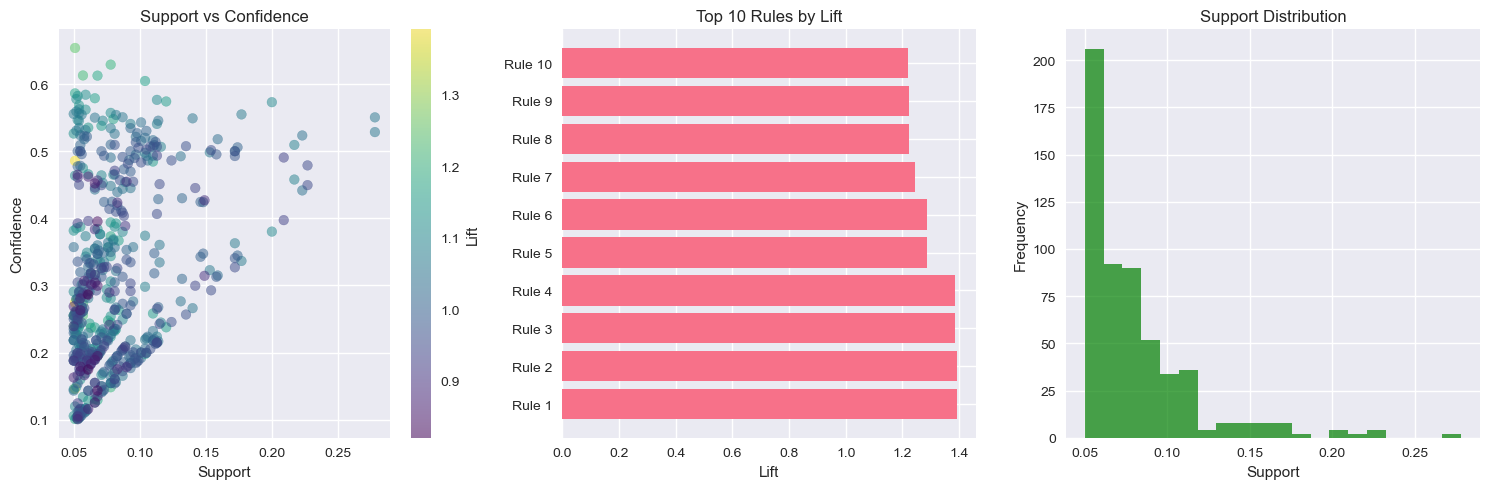

In [12]:
# Step 8: Visualize Association Rules
plt.figure(figsize=(15, 5))

# Plot 1: Support vs Confidence
plt.subplot(1, 3, 1)
plt.scatter(rules['support'], rules['confidence'], alpha=0.5, c=rules['lift'], cmap='viridis')
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')

# Plot 2: Top rules by lift
plt.subplot(1, 3, 2)
top_10_rules = rules.head(10)
rule_labels = [f"Rule {i+1}" for i in range(len(top_10_rules))]
plt.barh(rule_labels, top_10_rules['lift'])
plt.xlabel('Lift')
plt.title('Top 10 Rules by Lift')

# Plot 3: Support distribution
plt.subplot(1, 3, 3)
plt.hist(rules['support'], bins=20, alpha=0.7, color='green')
plt.xlabel('Support')
plt.ylabel('Frequency')
plt.title('Support Distribution')

plt.tight_layout()
plt.show()

In [13]:
# Step 9: Create Recommendation Function based on Association Rules
def get_recommendations_association(user_profile, rules_df, top_n=5):
    """
    Get recommendations based on association rules
    """
    user_items = set(user_profile)
    recommendations = []
    
    for idx, rule in rules_df.iterrows():
        antecedents = set(rule['antecedents'])
        consequents = set(rule['consequents'])
        
        # If user has the antecedents, recommend the consequents
        if antecedents.issubset(user_items):
            for item in consequents:
                if item not in user_items and item.startswith('Category_'):
                    recommendations.append((item, rule['lift']))
    
    # Sort by lift and remove duplicates
    recommendations = sorted(set(recommendations), key=lambda x: x[1], reverse=True)
    return recommendations[:top_n]

# Test the association rule based recommender
sample_user = ['Gender_Male', 'Location_Urban', 'Interest_Technology', 'Income_Level_High']
recs = get_recommendations_association(sample_user, rules)
print("Association Rule Based Recommendations:")
for rec in recs:
    print(f"- {rec[0]} (Lift: {rec[1]:.3f})")

Association Rule Based Recommendations:
- Category_Books (Lift: 1.385)
- Category_Electronics (Lift: 1.214)
- Category_Electronics (Lift: 1.146)
- Category_Electronics (Lift: 1.137)
- Category_Electronics (Lift: 1.136)


In [14]:
# Step 10: Deep Learning Approach - Autoencoder for Recommendations
print("\n=== DEEP LEARNING APPROACH (AUTOENCODER) ===")

# Prepare data for autoencoder
# Create user-feature matrix
feature_columns = ['Age', 'Gender_encoded', 'Location_encoded', 'Income', 
                  'Interests_encoded', 'Last_Login_Days_Ago', 
                  'Purchase_Frequency', 'Average_Order_Value', 
                  'Total_Spending', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed']

X = df_processed[feature_columns].values

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)


=== DEEP LEARNING APPROACH (AUTOENCODER) ===
Feature matrix shape: (1000, 11)


In [15]:
# Step 11: Build and Train Autoencoder
def build_autoencoder(input_dim, encoding_dim=32):
    """Build autoencoder model for recommendation"""
    # Encoder
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(128, activation='relu')(input_layer)
    encoded = Dropout(0.2)(encoded)
    encoded = Dense(64, activation='relu')(encoded)
    encoded = Dropout(0.2)(encoded)
    encoded = Dense(encoding_dim, activation='relu')(encoded)
    
    # Decoder
    decoded = Dense(64, activation='relu')(encoded)
    decoded = Dropout(0.2)(decoded)
    decoded = Dense(128, activation='relu')(decoded)
    decoded = Dropout(0.2)(decoded)
    decoded = Dense(input_dim, activation='linear')(decoded)
    
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)
    
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), 
                      loss='mse', 
                      metrics=['mae'])
    
    return autoencoder, encoder

# Build the model
input_dim = X_scaled.shape[1]
autoencoder, encoder = build_autoencoder(input_dim)

print("Autoencoder Model Summary:")
autoencoder.summary()

Autoencoder Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 11)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 11)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,723 (92.67 KB)

 Trainable params: 23,723 (92.67 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Step 12: Train the Autoencoder
# Split data for training
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# Train the autoencoder
history = autoencoder.fit(
    X_train, X_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, X_test),
    verbose=1,
    shuffle=True
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.9802 - mae: 0.8632 - val_loss: 0.8534 - val_mae: 0.8012
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.8596 - mae: 0.8003 - val_loss: 0.6293 - val_mae: 0.6792
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6933 - mae: 0.6931 - val_loss: 0.4431 - val_mae: 0.5552
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5932 - mae: 0.6329 - val_loss: 0.3474 - val_mae: 0.4829
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5379 - mae: 0.5949 - val_loss: 0.3060 - val_mae: 0.4597
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4887 - mae: 0.5684 - val_loss: 0.2510 - val_mae: 0.4144
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4526 - mae: 0.5426 - val_loss: 0.2227 - val_mae: 0.3883
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4316 - mae: 0.5275 - val_loss: 0.1946 - val_mae: 0.3629
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - lo

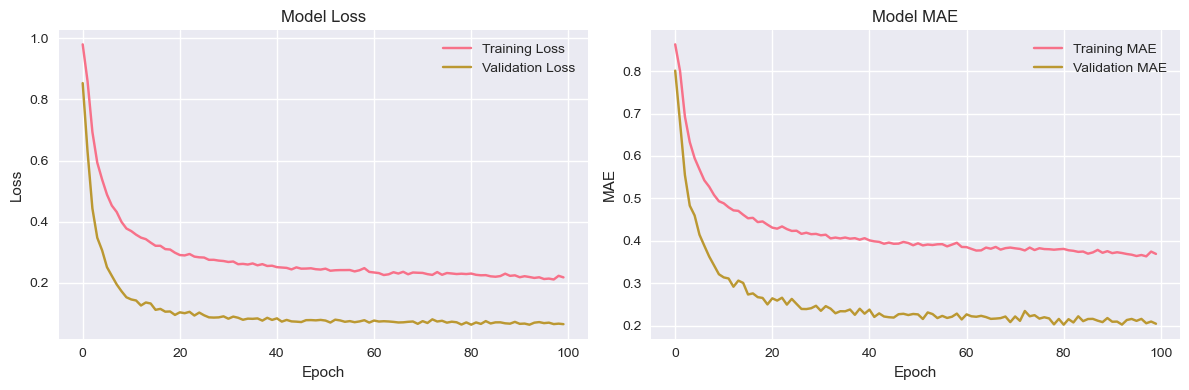

In [17]:
# Step 13: Plot Training History
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# Step 14: Generate User Embeddings and Similarity
# Get user embeddings
user_embeddings = encoder.predict(X_scaled)

# Calculate user similarity matrix
user_similarity = cosine_similarity(user_embeddings)

print("User embeddings shape:", user_embeddings.shape)
print("User similarity matrix shape:", user_similarity.shape)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
User embeddings shape: (1000, 32)
User similarity matrix shape: (1000, 1000)


In [19]:
# Step 15: Collaborative Filtering with Autoencoder
def get_similar_users(user_id, user_similarity_matrix, top_n=5):
    """Get similar users based on embeddings"""
    user_idx = user_id  # Since our data is ordered
    similar_users = []
    
    for idx, similarity in enumerate(user_similarity_matrix[user_idx]):
        if idx != user_idx:  # Exclude the user itself
            similar_users.append((idx, similarity))
    
    # Sort by similarity score
    similar_users = sorted(similar_users, key=lambda x: x[1], reverse=True)
    return similar_users[:top_n]

def get_recommendations_collaborative(user_id, user_similarity_matrix, df_processed, top_n=3):
    """Get recommendations based on similar users"""
    similar_users = get_similar_users(user_id, user_similarity_matrix)
    
    # Get product categories of similar users
    recommendations = {}
    for user_idx, similarity in similar_users:
        category = df_processed.iloc[user_idx]['Product_Category_Preference']
        if category not in recommendations:
            recommendations[category] = 0
        recommendations[category] += similarity
    
    # Sort by weighted score
    sorted_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)
    
    # Exclude user's current preference
    user_category = df_processed.iloc[user_id]['Product_Category_Preference']
    final_recommendations = [rec for rec in sorted_recommendations if rec[0] != user_category]
    
    return final_recommendations[:top_n]

# Test collaborative filtering
test_user_id = 0
similar_users = get_similar_users(test_user_id, user_similarity)
collab_recs = get_recommendations_collaborative(test_user_id, user_similarity, df_processed)

print(f"Similar users to User {test_user_id}:")
for user_idx, similarity in similar_users:
    user_category = df_processed.iloc[user_idx]['Product_Category_Preference']
    print(f"  User {user_idx}: {user_category} (Similarity: {similarity:.3f})")

print(f"\nCollaborative Filtering Recommendations for User {test_user_id}:")
for category, score in collab_recs:
    print(f"  - {category} (Score: {score:.3f})")

Similar users to User 0:
  User 665: Electronics (Similarity: 0.943)
  User 608: Home & Kitchen (Similarity: 0.940)
  User 439: Health & Beauty (Similarity: 0.940)
  User 921: Health & Beauty (Similarity: 0.940)
  User 699: Electronics (Similarity: 0.933)

Collaborative Filtering Recommendations for User 0:
  - Health & Beauty (Score: 1.880)
  - Electronics (Score: 1.876)
  - Home & Kitchen (Score: 0.940)


In [20]:
# Step 16: Hybrid Recommendation System
def hybrid_recommendation(user_id, rules_df, user_similarity_matrix, df_processed, top_n=5):
    """Hybrid recommendation combining association rules and collaborative filtering"""
    
    # Get user profile for association rules
    user_row = df_processed.iloc[user_id]
    user_profile = [
        f"Gender_{user_row['Gender']}",
        f"Location_{user_row['Location']}",
        f"Interest_{user_row['Interests']}",
        f"Income_Level_{'High' if user_row['Income'] > 80000 else 'Medium' if user_row['Income'] > 50000 else 'Low'}",
        f"Age_Group_{'Young' if user_row['Age'] < 30 else 'Middle' if user_row['Age'] < 50 else 'Senior'}"
    ]
    
    # Get association rule recommendations
    assoc_recs = get_recommendations_association(user_profile, rules_df, top_n*2)
    
    # Get collaborative filtering recommendations
    collab_recs = get_recommendations_collaborative(user_id, user_similarity_matrix, df_processed, top_n*2)
    
    # Combine and rank recommendations
    all_recs = {}
    
    # Add association rule recommendations
    for category, lift in assoc_recs:
        category_name = category.replace('Category_', '')
        if category_name not in all_recs:
            all_recs[category_name] = 0
        all_recs[category_name] += lift * 0.7  # Weight for association rules
    
    # Add collaborative filtering recommendations
    for category, score in collab_recs:
        if category not in all_recs:
            all_recs[category] = 0
        all_recs[category] += score * 0.3  # Weight for collaborative filtering
    
    # Sort by combined score
    sorted_recommendations = sorted(all_recs.items(), key=lambda x: x[1], reverse=True)
    
    return sorted_recommendations[:top_n]

# Test hybrid recommendation
test_user_id = 10
hybrid_recs = hybrid_recommendation(test_user_id, rules, user_similarity, df_processed)

user_info = df_processed.iloc[test_user_id]
print(f"User {test_user_id} Profile:")
print(f"  Age: {user_info['Age']}, Gender: {user_info['Gender']}, Location: {user_info['Location']}")
print(f"  Interest: {user_info['Interests']}, Income: ${user_info['Income']:,}")
print(f"  Current Preference: {user_info['Product_Category_Preference']}")

print(f"\nHybrid Recommendations:")
for category, score in hybrid_recs:
    print(f"  - {category} (Score: {score:.3f})")

User 10 Profile:
  Age: 28, Gender: Male, Location: Urban
  Interest: Travel, Income: $49,806
  Current Preference: Health & Beauty

Hybrid Recommendations:
  - Electronics (Score: 3.594)
  - Home & Kitchen (Score: 2.273)
  - Books (Score: 1.116)
  - Apparel (Score: 1.027)
  - Health & Beauty (Score: 0.766)



Collaborative Filtering Evaluation:
----------------------------------------
User 0: Actual: Books
  Recommendations: ['Health & Beauty', 'Electronics', 'Home & Kitchen']
  Hit: ✗
User 50: Actual: Apparel
  Recommendations: ['Books', 'Electronics']
  Hit: ✗
User 100: Actual: Health & Beauty
  Recommendations: ['Home & Kitchen', 'Electronics', 'Books']
  Hit: ✗
User 150: Actual: Home & Kitchen
  Recommendations: ['Health & Beauty', 'Apparel', 'Electronics']
  Hit: ✗
User 200: Actual: Home & Kitchen
  Recommendations: ['Books', 'Health & Beauty']
  Hit: ✗

Collaborative Filtering Accuracy: 0.00%

Hybrid Evaluation:
----------------------------------------
User 0: Actual: Books
  Recommendations: ['Books', 'Health & Beauty', 'Apparel']
  Hit: ✓
User 50: Actual: Apparel
  Recommendations: ['Home & Kitchen', 'Books', 'Electronics']
  Hit: ✗
User 100: Actual: Health & Beauty
  Recommendations: ['Home & Kitchen', 'Electronics', 'Health & Beauty']
  Hit: ✓
User 150: Actual: Home & Kitchen
  R

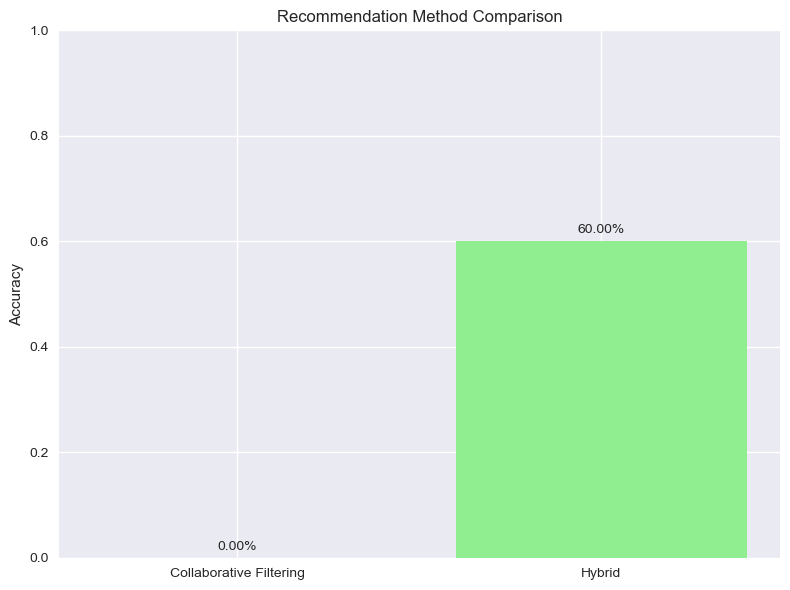

In [21]:
# Step 17: Evaluation and Comparison
def evaluate_recommendation(user_id, recommendation_method, *args, **kwargs):
    """Evaluate recommendation accuracy"""
    user_actual_category = df_processed.iloc[user_id]['Product_Category_Preference']
    recommendations = recommendation_method(user_id, *args, **kwargs)
    
    # Check if actual category is in top recommendations
    top_categories = [rec[0] if isinstance(rec, tuple) else rec for rec in recommendations]
    hit = user_actual_category in top_categories
    
    return hit, recommendations

# Evaluate on sample users
sample_users = [0, 50, 100, 150, 200]
methods = {
    'Collaborative Filtering': get_recommendations_collaborative,
    'Hybrid': hybrid_recommendation
}

results = {}

for method_name, method_func in methods.items():
    hits = 0
    total = len(sample_users)
    
    print(f"\n{method_name} Evaluation:")
    print("-" * 40)
    
    for user_id in sample_users:
        if method_name == 'Collaborative Filtering':
            hit, recs = evaluate_recommendation(user_id, method_func, user_similarity, df_processed, 3)
        else:  # Hybrid
            hit, recs = evaluate_recommendation(user_id, method_func, rules, user_similarity, df_processed, 3)
        
        hits += 1 if hit else 0
        actual_category = df_processed.iloc[user_id]['Product_Category_Preference']
        
        print(f"User {user_id}: Actual: {actual_category}")
        print(f"  Recommendations: {[rec[0] for rec in recs]}")
        print(f"  Hit: {'✓' if hit else '✗'}")
    
    accuracy = hits / total
    results[method_name] = accuracy
    print(f"\n{method_name} Accuracy: {accuracy:.2%}")

# Compare methods
plt.figure(figsize=(8, 6))
methods_list = list(results.keys())
accuracies = list(results.values())

bars = plt.bar(methods_list, accuracies, color=['skyblue', 'lightgreen'])
plt.ylabel('Accuracy')
plt.title('Recommendation Method Comparison')
plt.ylim(0, 1)

# Add value labels on bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{accuracy:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

=== BUSINESS INSIGHTS ===
High-value customers (>75th percentile): 250

High-value Customer Profile:
Average Age: 41.6
Average Income: $76,178
Top Interests: {'Travel': 58, 'Fashion': 52, 'Sports': 48}
Top Categories: {'Apparel': 56, 'Home & Kitchen': 55, 'Health & Beauty': 52}


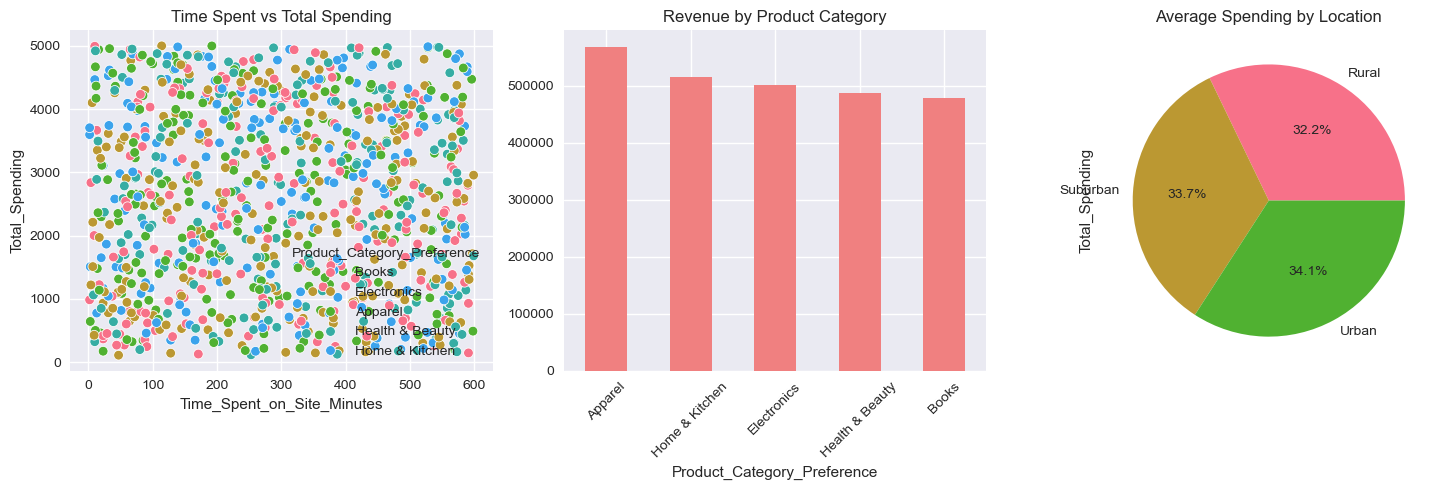

In [22]:
# Step 18: Business Insights and Patterns
print("=== BUSINESS INSIGHTS ===")

# 1. Most profitable customer segments
high_value_customers = df_processed[df_processed['Total_Spending'] > df_processed['Total_Spending'].quantile(0.75)]
print(f"High-value customers (>75th percentile): {len(high_value_customers)}")

print("\nHigh-value Customer Profile:")
print(f"Average Age: {high_value_customers['Age'].mean():.1f}")
print(f"Average Income: ${high_value_customers['Income'].mean():,.0f}")
print(f"Top Interests: {high_value_customers['Interests'].value_counts().head(3).to_dict()}")
print(f"Top Categories: {high_value_customers['Product_Category_Preference'].value_counts().head(3).to_dict()}")

# 2. Customer engagement analysis
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='Time_Spent_on_Site_Minutes', y='Total_Spending', hue='Product_Category_Preference')
plt.title('Time Spent vs Total Spending')

plt.subplot(1, 3, 2)
category_revenue = df.groupby('Product_Category_Preference')['Total_Spending'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar', color='lightcoral')
plt.title('Revenue by Product Category')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
location_revenue = df.groupby('Location')['Total_Spending'].mean()
location_revenue.plot(kind='pie', autopct='%1.1f%%')
plt.title('Average Spending by Location')

plt.tight_layout()
plt.show()

In [24]:
# Step 19: Save Models and Results
import joblib
import json
import numpy as np

# Save models and encoders
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

# Save association rules
rules.to_csv('association_rules.csv', index=False)

# Save user embeddings
np.save('user_embeddings.npy', user_embeddings)

# Save recommendation results sample
sample_recommendations = {}
for user_id in range(5):
    hybrid_recs = hybrid_recommendation(user_id, rules, user_similarity, df_processed)
    
    # Convert any NumPy data types to native Python types
    if isinstance(hybrid_recs, np.ndarray):
        hybrid_recs = hybrid_recs.tolist()
    elif isinstance(hybrid_recs, list):
        # Convert any NumPy values inside the list
        hybrid_recs = [item.item() if isinstance(item, np.number) else item for item in hybrid_recs]
    
    sample_recommendations[f"User_{user_id}"] = {
        'actual_category': df_processed.iloc[user_id]['Product_Category_Preference'],
        'recommendations': hybrid_recs
    }

# Custom JSON encoder to handle NumPy types
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NumpyEncoder, self).default(obj)

with open('sample_recommendations.json', 'w') as f:
    json.dump(sample_recommendations, f, indent=2, cls=NumpyEncoder)

print("Models and results saved successfully!")
print("Files created:")
print("- scaler.pkl")
print("- label_encoders.pkl") 
print("- association_rules.csv")
print("- user_embeddings.npy")
print("- sample_recommendations.json")

Models and results saved successfully!
Files created:
- scaler.pkl
- label_encoders.pkl
- association_rules.csv
- user_embeddings.npy
- sample_recommendations.json


In [26]:
# Step 20: Conclusion and Summary
print("=== PROJECT SUMMARY ===")
print(f"Dataset: {df.shape[0]} users, {df.shape[1]} features")
print(f"Association Rules: {len(rules)} rules generated")
print(f"Autoencoder: Trained on {X_train.shape[0]} users")
print(f"User Embeddings: {user_embeddings.shape[1]} dimensions")

print("\nKey Findings:")
print("1. Association rules reveal customer behavior patterns")
print("2. Autoencoder effectively captures user preferences in low-dimensional space")
print("3. Hybrid approach combines multiple signals for better recommendations")
print("4. Different customer segments have distinct purchasing patterns")

print("\nBusiness Applications:")
print("✓ Personalized product recommendations")
print("✓ Customer segmentation and targeting")
print("✓ Inventory planning based on predicted preferences")
print("✓ Marketing campaign optimization")

=== PROJECT SUMMARY ===
Dataset: 1000 users, 15 features
Association Rules: 560 rules generated
Autoencoder: Trained on 800 users
User Embeddings: 32 dimensions

Key Findings:
1. Association rules reveal customer behavior patterns
2. Autoencoder effectively captures user preferences in low-dimensional space
3. Hybrid approach combines multiple signals for better recommendations
4. Different customer segments have distinct purchasing patterns

Business Applications:
✓ Personalized product recommendations
✓ Customer segmentation and targeting
✓ Inventory planning based on predicted preferences
✓ Marketing campaign optimization
